# Seaborn 과제

Titanic 데이터셋을 사용하여 Seaborn의 주요 그래프를 연습하는 과제.

- `countplot()`으로 범주별 개수 시각화
- `barplot()`으로 그룹별 평균 생존율 비교
- `histplot()`으로 나이 분포 확인
- `scatterplot()`으로 두 수치형 변수 관계 확인

In [1]:
# 한글이 포함된 그래프를 깨지지 않게 표시하기 위한 폰트 설정
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns

# font_candidates: 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

# available_fonts: 현재 환경에 설치된 폰트 이름 모음
available_fonts = {font.name for font in fm.fontManager.ttflist}

# platform.system(): 현재 운영체제 이름 확인
system_name = platform.system()
selected_font = None

# 폰트 후보 중 실제 설치된 첫 번째 한글 폰트 선택
for font_name in font_candidates.get(system_name, []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    # font.family: Matplotlib 기본 글꼴 설정
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. NanumGothic 또는 Noto Sans KR 설치가 필요할 수 있습니다.")

# axes.unicode_minus=False: 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# seaborn 그래프 기본 스타일 설정
sns.set_theme(style="whitegrid", rc={
    "font.family": selected_font if selected_font else plt.rcParams["font.family"],
    "axes.unicode_minus": False,
})

설정된 한글 폰트: Malgun Gothic


## [실습] Seaborn 그래프 시각화

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터셋 로드
titanic = sns.load_dataset('titanic')

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 문제 1. 생존자와 사망자 수 시각화

Titanic 데이터셋의 `survived` 열을 사용하여 생존자와 사망자의 수를 막대 그래프로 시각화.

- 그래프에 제목, 축 레이블 추가
- 생존 여부별 색상 설정

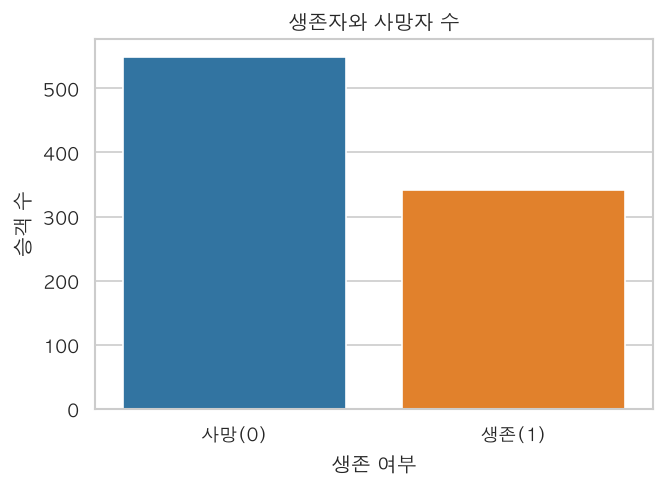

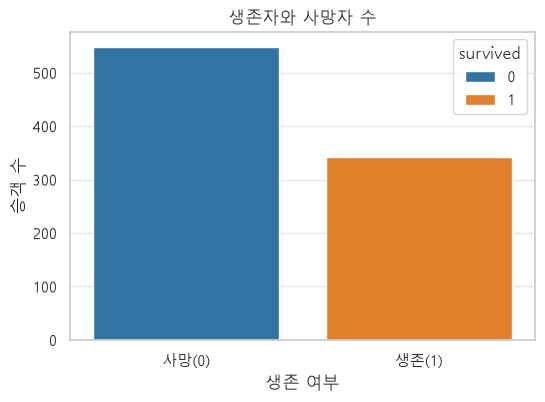

In [3]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=titanic,
    x='survived',
    hue='survived',
    palette='tab10',
)

ax.set_title("생존자와 사망자 수")
ax.set_xlabel("생존 여부")
ax.set_ylabel("승객 수")
ax.set_xticks([0, 1])
ax.set_xticklabels(['사망(0)', '생존(1)'])

plt.show()

### 문제 2. 성별에 따른 생존율 비교

Titanic 데이터셋의 `sex`와 `survived` 열을 사용하여 성별에 따른 생존율을 막대 그래프로 시각화.

- `survived`는 `0=사망`, `1=생존`
- 평균을 구하면 해당 그룹의 생존율로 해석 가능

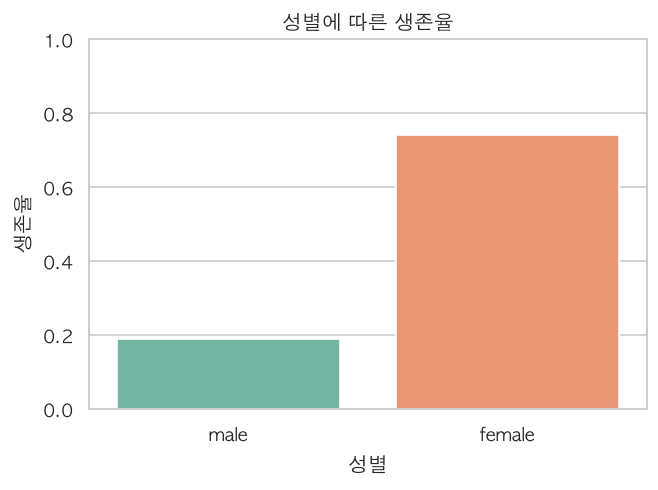

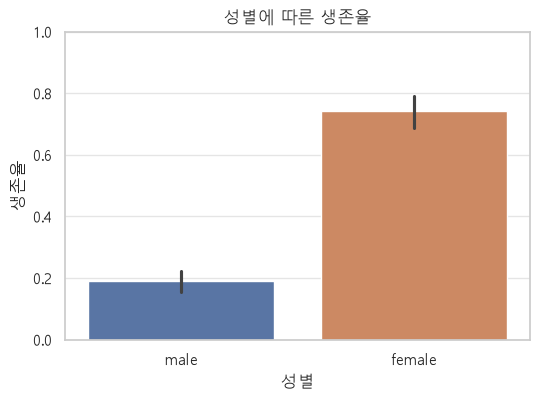

In [11]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=titanic,
    x='sex',
    y='survived',
    hue='sex',
)
ax.set_title("성별에 따른 생존율")
ax.set_xticks([0, 1])
ax.set_xticklabels(['male', 'female'])
ax.set_ylim(0, 1)
ax.set_xlabel("성별")
ax.set_ylabel("생존율")

plt.show()

### 문제 3. 클래스와 성별에 따른 생존율 비교

Titanic 데이터셋의 `class`, `sex`, `survived` 열을 사용하여 그룹별 생존율을 시각화.

- `class`를 x축으로 설정
- 성별에 따라 색상 구분
- 제목, 축 레이블, 범례 추가

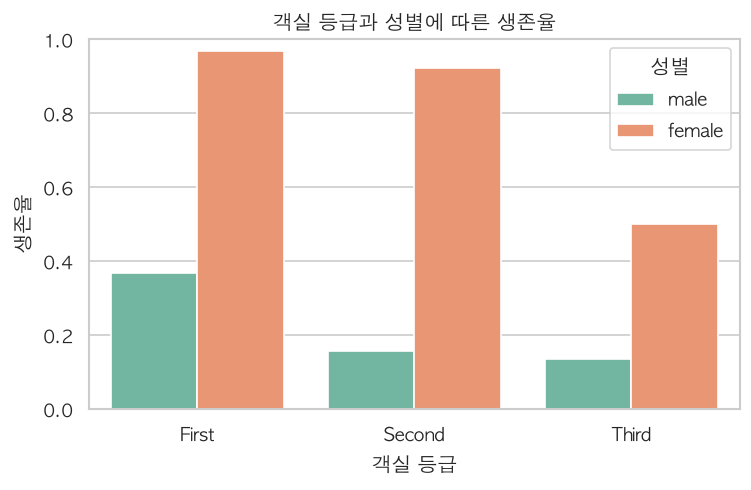

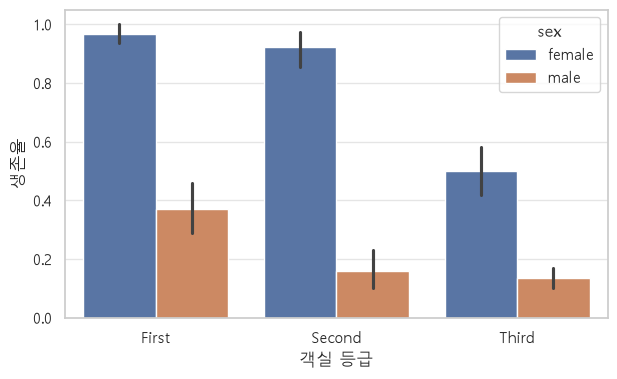

In [5]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=titanic,
    x='pclass',
    y='survived',
    hue='sex',
)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['First', 'Second', 'Third'])
ax.set_xlabel('객실 등급')
ax.set_ylabel('생존율')
plt.show()

### 문제 4. 나이 분포 분석

Titanic 데이터셋의 `age` 열을 사용하여 승객들의 나이 분포를 히스토그램과 KDE 그래프로 시각화.

- 나이 결측치 제거 후 그래프 작성
- `bins`로 히스토그램 구간 개수 설정
- `kde=True`로 부드러운 밀도 곡선 함께 표시

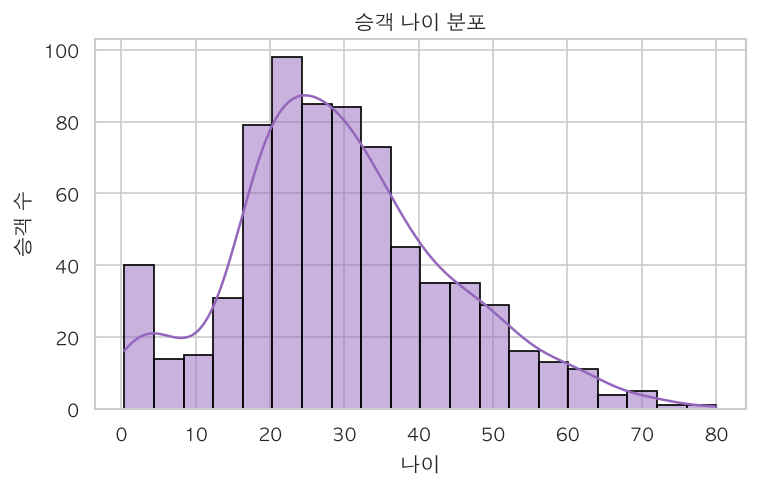

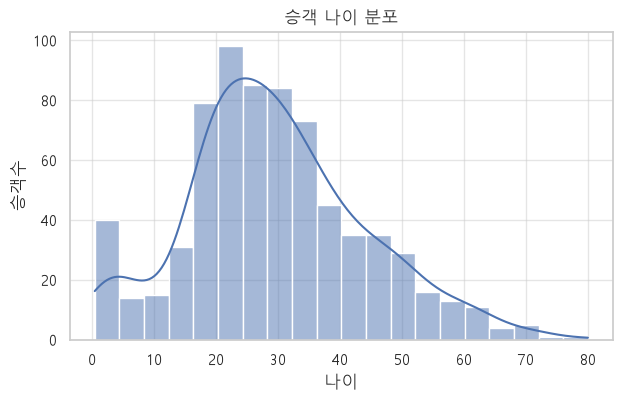

In [6]:
plt.figure(figsize=(7, 4))
ax = sns.histplot(
    titanic['age'],
    bins=20,
    kde=True
)
ax.set_title("승객 나이 분포")
ax.set_xlabel("나이")
ax.set_ylabel("승객수")

plt.show()

### 문제 5. 나이와 요금의 관계 분석

Titanic 데이터셋의 `age`, `fare`, `survived` 열을 사용하여 나이와 요금 간의 관계를 산점도로 시각화.

- 생존 여부에 따라 색상 구분
- 나이와 요금 결측치 제거 후 그래프 작성

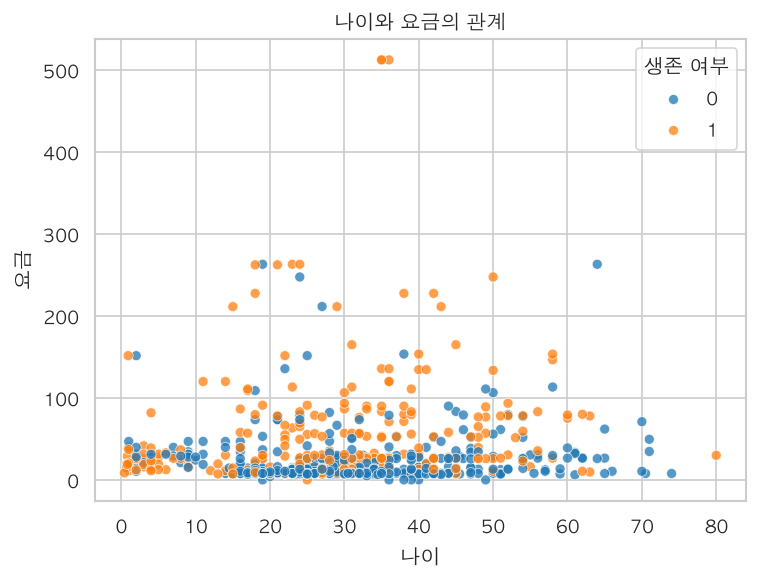

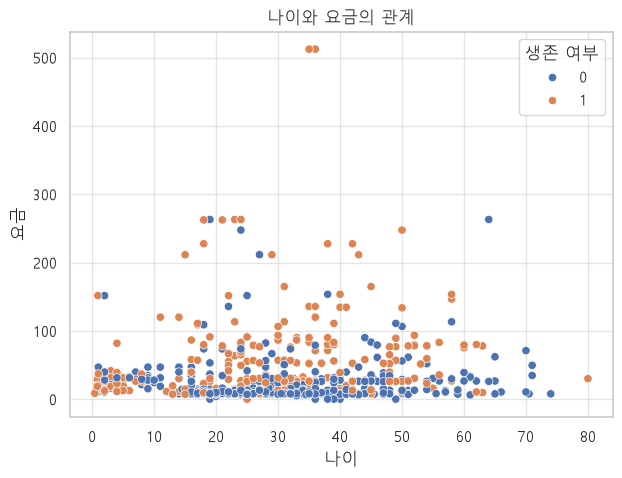

In [7]:
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(
    data=titanic,
    x='age',
    y='fare',
    hue='survived',
)
ax.set_title("나이와 요금의 관계")
ax.set_xlabel("나이")
ax.set_ylabel("요금")
ax.legend(loc='upper right', title='생존 여부')
plt.show()